# Image Generation Using Stable Diffusion XL

## Objective

The objective of this project is to generate ultra-realistic images using the Stable Diffusion XL (SDXL) model

### Import Required Libraries

In [1]:
import torch
from diffusers import StableDiffusionXLPipeline, DPMSolverSinglestepScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


### Loading the Stable Diffusion XL Model

In [2]:
pipe = StableDiffusionXLPipeline.from_pretrained("sd-community/sdxl-flash", torch_dtype=torch.float16).to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

### Configuring the DPM Solver Scheduler

In [31]:
pipe.scheduler = DPMSolverSinglestepScheduler.from_config(pipe.scheduler.config, timestep_spacing="trailing")

### Defining the Positive and Negative Prompt

In [32]:
Prompt = """ultra photorealistic wildlife photograph of a powerful Bengal tiger charging forward,
aggressive fighting stance, body low to the ground, muscles fully flexed,
mouth wide open in a fierce roar, sharp natural teeth visible,
intense realistic tiger eyes with natural reflections and emotion,
accurate animal anatomy, correct skeletal structure,
five toes per paw only, realistic claws, no extra fingers,
highly detailed fur texture with natural orange and black stripes,
dust and debris kicked up from the ground, frozen action moment,
natural outdoor environment, realistic lighting and shadows,
National Geographic wildlife photography style,
shot on professional DSLR camera, 85mm lens,
shallow depth of field, sharp focus, ultra detailed, 8k realism,
true-to-life colors, no stylization, no animation, masterpiece"""

negative_prompt = """cartoon, anime, illustration, CGI, 3d render,
stylized, fantasy, unreal engine look,
extra fingers, extra toes, six toes, incorrect anatomy,
mutated paws, deformed limbs,
fake eyes, glowing eyes, unrealistic eyes,
plastic fur, smooth skin, oversharpened,
motion blur on face, artifacts,
text, watermark, logo
"""

### Generating the Image

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['texture with natural orange and black stripes, dust and debris kicked up from the ground, frozen action moment, natural outdoor environment, realistic lighting and shadows, national geographic wildlife photography style, shot on professional dslr camera, 8 5 mm lens, shallow depth of field, sharp focus, ultra detailed, 8 k realism, true - to - life colors, no stylization, no animation, masterpiece']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['texture with natural orange and black stripes, dust and debris kicked up from the ground, frozen action moment, natural outdoor environment, realistic lighting and shadows, national geographic wildlife photography style, shot on professional dslr camera, 8 5 mm lens, shallow depth of field, sharp focus, ultra detailed, 8 k realism, true - to - life colors, no stylization, no animation

  0%|          | 0/40 [00:00<?, ?it/s]

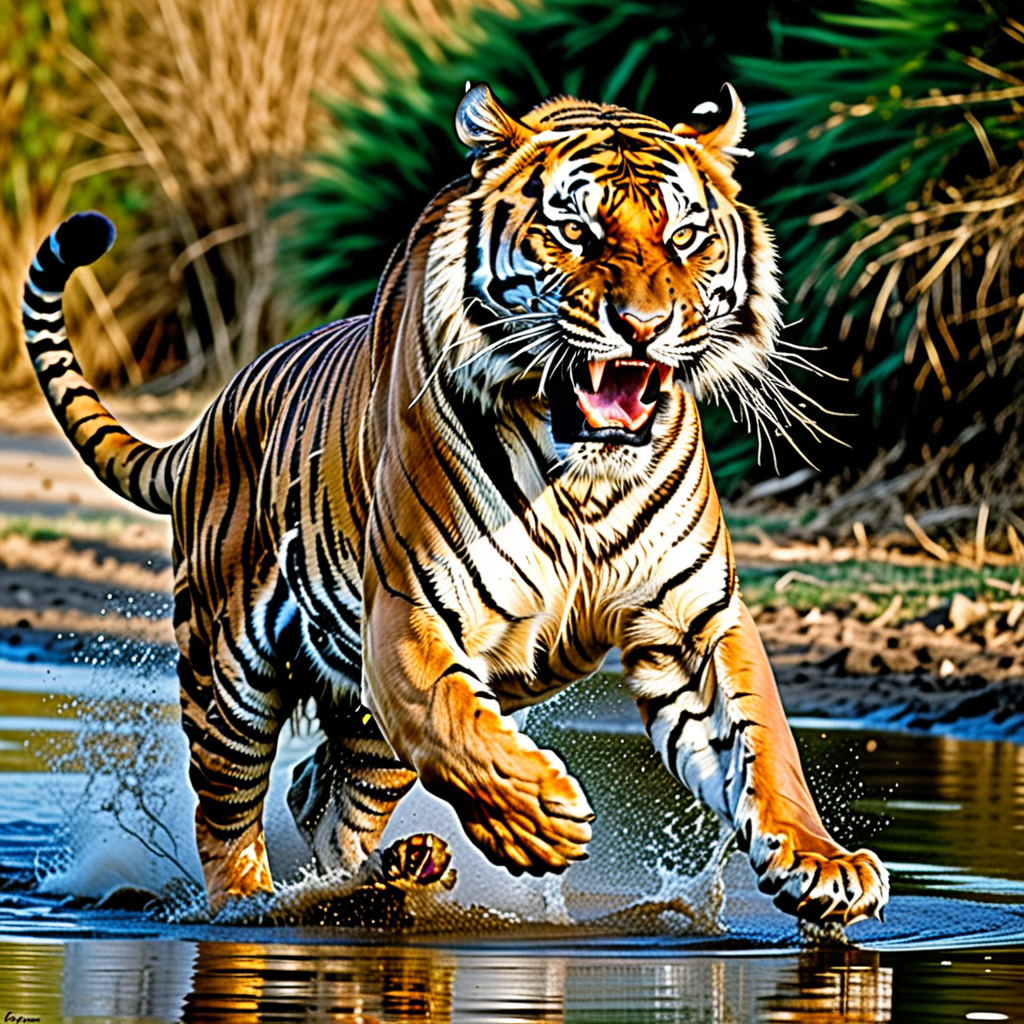

In [33]:
image = pipe(prompt= Prompt, negative_prompt= negative_prompt, num_inference_steps=40, guidance_scale=7.5).images[0]
display(image)

### Save the Image

In [34]:
image.save("Tiger_fight.png")